# Домашнее задание к семинару 07 (HW07)

Тема: кластеризация, внутренние метрики качества, PCA/t-SNE и "честный" unsupervised-эксперимент на синтетических данных.


#### 2.3.1. Загрузка данных и первичный анализ (для каждого датасета)

Для **каждого** из 3 выбранных CSV:

1) Загрузить CSV в `pandas.DataFrame`.  
2) Зафиксировать минимум:
   - `head()`, `info()`, базовые статистики (`describe()` или аналог);
   - проверка пропусков (кол-во/доли);
   - типы признаков (числовые / категориальные).  
3) Определить:
   - `X` – признаки (все столбцы, кроме `sample_id`);
   - `sample_id` хранить отдельно (для сохранения результатов).

In [279]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA


df1 = pd.read_csv("data/S07-hw-dataset-01.csv")
df2 = pd.read_csv("data/S07-hw-dataset-02.csv")
df3 = pd.read_csv("data/S07-hw-dataset-03.csv")

In [280]:
df1.head(5)

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [281]:
df2.head(5)

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [282]:
df3.head(5)

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [283]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [284]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [285]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


In [286]:
df1.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [287]:
df2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [288]:
df3.describe()

,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [289]:
df1.isna().mean().sort_values()

sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64

In [290]:
df2.isna().mean().sort_values()

sample_id    0.0
x1           0.0
x2           0.0
z_noise      0.0
dtype: float64

In [291]:
df3.isna().mean().sort_values()

sample_id    0.0
x1           0.0
x2           0.0
f_corr       0.0
f_noise      0.0
dtype: float64

In [292]:
df1.dtypes

sample_id      int64
f01          float64
f02          float64
f03          float64
f04          float64
f05          float64
f06          float64
f07          float64
f08          float64
dtype: object

In [293]:
df2.dtypes

sample_id      int64
x1           float64
x2           float64
z_noise      float64
dtype: object

In [294]:
df3.dtypes

sample_id      int64
x1           float64
x2           float64
f_corr       float64
f_noise      float64
dtype: object

In [295]:
sample_id1 = df1["sample_id"].copy()
X1 = df1.drop(columns=["sample_id"])

sample_id2 = df2["sample_id"].copy()
X2 = df2.drop(columns=["sample_id"])

sample_id3 = df3["sample_id"].copy()
X3 = df3.drop(columns=["sample_id"])


#### 2.3.2. Препроцессинг (обязательно)

Для каждого датасета оформите препроцессинг **явно** и применяйте его одинаково ко всем моделям данного датасета.

Минимум:

- масштабирование числовых признаков: `StandardScaler`;
- если есть пропуски – обработать (`SimpleImputer`);
- если есть категориальные признаки (dataset-04) – один из вариантов:
  - закодировать (`OneHotEncoder(handle_unknown="ignore")`), **или**
  - осознанно исключить категориальные признаки и объяснить почему (в отчёте).

Рекомендация: использовать `Pipeline`/`ColumnTransformer` (не обязательно идеально, но логика должна быть понятной).

In [296]:
prep1 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X1p = prep1.fit_transform(X1)
X1p.shape

(12000, 8)

In [297]:
prep2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X2p = prep2.fit_transform(X2)
X2p.shape

(8000, 3)

In [298]:
prep3 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X3p = prep3.fit_transform(X3)
X3p.shape

(15000, 4)

#### 2.3.3. Модели недели 7 (для каждого датасета – минимум 2 алгоритма)

Для **каждого датасета** сравните минимум **2** алгоритма:

1) **KMeans** (обязательно):
   - подобрать `k` в разумном диапазоне (например, 2…20);
   - фиксировать `random_state` и `n_init`;
   - показать хотя бы один график "метрика vs k" (например, silhouette vs k).

2) **Один алгоритм на выбор** (обязательно):
   - `DBSCAN` (подбор `eps` и `min_samples`), **или**
   - `AgglomerativeClustering` (подбор `k` + выбор `linkage`, хотя бы 2 варианта).

df1 best_k = 2 best_sil = 0.5216395622404243


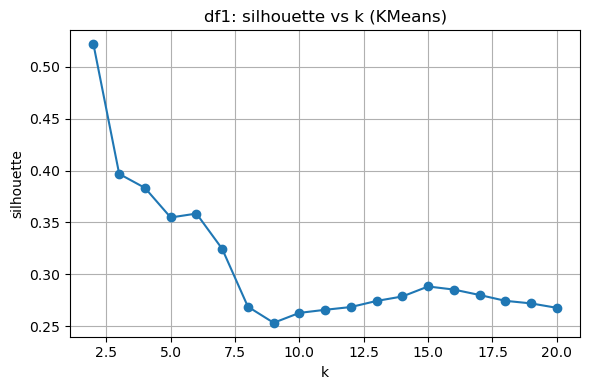

In [299]:
ks = range(2, 21)
sil_k = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X1p)
    sil = silhouette_score(X1p, labels)
    sil_k.append(sil)

best_k1 = int(list(ks)[int(np.argmax(sil_k))])
print("df1 best_k =", best_k1, "best_sil =", max(sil_k))

plt.figure(figsize=(6,4))
plt.plot(list(ks), sil_k, marker="o")
plt.title("df1: silhouette vs k (KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/df1_kmeans_sil_vs_k.png", dpi=150)
plt.show()

km1 = KMeans(n_clusters=best_k1, random_state=42, n_init=10)
labels_km1 = km1.fit_predict(X1p)


In [300]:
eps_list = [0.3, 0.5, 0.7, 1.0, 1.3]
ms_list = [5, 10]

best_db1 = None

for eps in eps_list:
    for ms in ms_list:
        dbs = DBSCAN(eps=eps, min_samples=ms)
        labels = dbs.fit_predict(X1p)
        noise_frac = float((labels == -1).mean())

        mask = labels != -1
        if mask.sum() >= 3 and len(np.unique(labels[mask])) >= 2:
            sil = float(silhouette_score(X1p[mask], labels[mask]))
            print("eps", eps, "ms", ms, "noise", round(noise_frac,3), "sil", round(sil,3))

            if (best_db1 is None) or (sil > best_db1["sil"]):
                best_db1 = {"eps": eps, "min_samples": ms, "noise": noise_frac, "sil": sil, "labels": labels}

best_db1


eps 0.3 ms 5 noise 0.433 sil -0.122
eps 0.3 ms 10 noise 0.622 sil 0.165
eps 0.5 ms 5 noise 0.034 sil 0.283
eps 0.5 ms 10 noise 0.062 sil 0.366
eps 0.7 ms 5 noise 0.004 sil 0.38
eps 0.7 ms 10 noise 0.007 sil 0.381
eps 1.0 ms 5 noise 0.001 sil 0.384
eps 1.0 ms 10 noise 0.001 sil 0.384
eps 1.3 ms 5 noise 0.0 sil 0.383
eps 1.3 ms 10 noise 0.0 sil 0.383


{'eps': 1.0,
 'min_samples': 10,
 'noise': 0.0006666666666666666,
 'sil': 0.383734806495279,
 'labels': array([0, 1, 1, ..., 3, 1, 2])}

df2 best_k = 2 best_sil = 0.3068610017701601


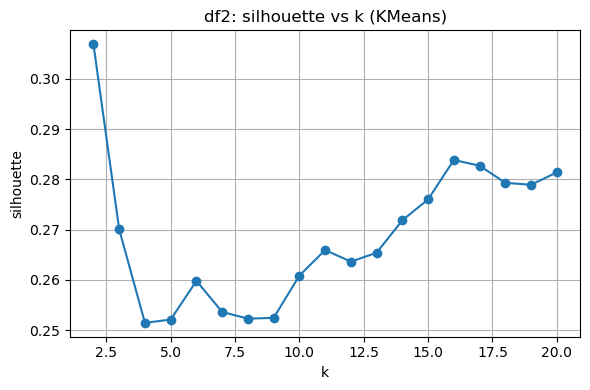

In [301]:
ks = range(2, 21)
sil_k = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X2p)
    sil = silhouette_score(X2p, labels)
    sil_k.append(sil)

best_k2 = int(list(ks)[int(np.argmax(sil_k))])
print("df2 best_k =", best_k2, "best_sil =", max(sil_k))

plt.figure(figsize=(6,4))
plt.plot(list(ks), sil_k, marker="o")
plt.title("df2: silhouette vs k (KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/df2_kmeans_sil_vs_k.png", dpi=150)
plt.show()

km2 = KMeans(n_clusters=best_k2, random_state=42, n_init=10)
labels_km2 = km2.fit_predict(X2p)


In [302]:
eps_list = [0.3, 0.5, 0.7, 1.0, 1.3]
ms_list = [5, 10]

best_db2 = None

for eps in eps_list:
    for ms in ms_list:
        dbs = DBSCAN(eps=eps, min_samples=ms)
        labels = dbs.fit_predict(X2p)
        noise_frac = float((labels == -1).mean())

        mask = labels != -1
        if mask.sum() >= 3 and len(np.unique(labels[mask])) >= 2:
            sil = float(silhouette_score(X2p[mask], labels[mask]))
            print("eps", eps, "ms", ms, "noise", round(noise_frac,3), "sil", round(sil,3))

            if (best_db2 is None) or (sil > best_db2["sil"]):
                best_db2 = {"eps": eps, "min_samples": ms, "noise": noise_frac, "sil": sil, "labels": labels}

best_db2


eps 0.3 ms 5 noise 0.072 sil 0.085
eps 0.5 ms 5 noise 0.045 sil -0.058
eps 0.5 ms 10 noise 0.064 sil 0.251
eps 0.7 ms 10 noise 0.036 sil 0.305


{'eps': 0.7,
 'min_samples': 10,
 'noise': 0.036375,
 'sil': 0.3049523469313708,
 'labels': array([-1, -1,  0, ...,  0,  0,  0])}

df3 best_k = 3 best_sil = 0.31554470037825183


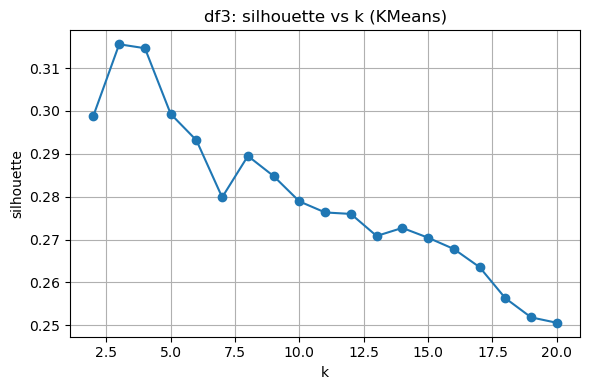

In [303]:
ks = range(2, 21)
sil_k = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X3p)
    sil = silhouette_score(X3p, labels)
    sil_k.append(sil)

best_k3 = int(list(ks)[int(np.argmax(sil_k))])
print("df3 best_k =", best_k3, "best_sil =", max(sil_k))

plt.figure(figsize=(6,4))
plt.plot(list(ks), sil_k, marker="o")
plt.title("df3: silhouette vs k (KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/df3_kmeans_sil_vs_k.png", dpi=150)
plt.show()

km3 = KMeans(n_clusters=best_k3, random_state=42, n_init=10)
labels_km3 = km3.fit_predict(X3p)


In [304]:
eps_list = [0.3, 0.5, 0.7, 1.0, 1.3]
ms_list = [5, 10]

best_db3 = None

for eps in eps_list:
    for ms in ms_list:
        dbs = DBSCAN(eps=eps, min_samples=ms)
        labels = dbs.fit_predict(X3p)
        noise_frac = float((labels == -1).mean())

        mask = labels != -1
        if mask.sum() >= 3 and len(np.unique(labels[mask])) >= 2:
            sil = float(silhouette_score(X3p[mask], labels[mask]))
            print("eps", eps, "ms", ms, "noise", round(noise_frac,3), "sil", round(sil,3))

            if (best_db3 is None) or (sil > best_db3["sil"]):
                best_db3 = {"eps": eps, "min_samples": ms, "noise": noise_frac, "sil": sil, "labels": labels}

best_db3


eps 0.3 ms 5 noise 0.125 sil -0.236
eps 0.3 ms 10 noise 0.216 sil 0.038
eps 0.5 ms 5 noise 0.022 sil -0.104
eps 0.5 ms 10 noise 0.032 sil 0.142


{'eps': 0.5,
 'min_samples': 10,
 'noise': 0.0324,
 'sil': 0.14243088104506604,
 'labels': array([ 0, -1, -1, ...,  1,  1,  1])}

#### 2.3.4. Метрики качества (обязательно)

Для каждого датасета и каждого сравниваемого алгоритма посчитать:

- `silhouette_score`
- `davies_bouldin_score`
- `calinski_harabasz_score`

Важно для DBSCAN:

- учесть шум (`label = -1`):
  - явно вывести долю шума,
  - метрики считать либо на non-noise точках (и это указать), либо честно объяснить иной выбор.

In [305]:
sil_km1 = float(silhouette_score(X1p, labels_km1))
db_km1  = float(davies_bouldin_score(X1p, labels_km1))
ch_km1  = float(calinski_harabasz_score(X1p, labels_km1))
print("df1 KMeans:", sil_km1, db_km1, ch_km1)

df1 KMeans: 0.5216395622404243 0.6853295219054456 11786.954622671532


In [306]:
sil_km2 = float(silhouette_score(X2p, labels_km2))
db_km2  = float(davies_bouldin_score(X2p, labels_km2))
ch_km2  = float(calinski_harabasz_score(X2p, labels_km2))
print("df2 KMeans:", sil_km2, db_km2, ch_km2)

df2 KMeans: 0.3068610017701601 1.3234721699867644 3573.3933329348392


In [307]:
sil_km3 = float(silhouette_score(X3p, labels_km3))
db_km3  = float(davies_bouldin_score(X3p, labels_km3))
ch_km3  = float(calinski_harabasz_score(X3p, labels_km3))
print("df3 KMeans:", sil_km3, db_km3, ch_km3)

df3 KMeans: 0.31554470037825183 1.1577256320598661 6957.162639510167


In [308]:
labels_db1 = best_db1["labels"]
noise_frac1 = float((labels_db1 == -1).mean())
print("df1 DBSCAN noise_frac =", noise_frac1)

mask1 = labels_db1 != -1
sil_df1 = float(silhouette_score(X1p[mask1], labels_db1[mask1]))
db_df1  = float(davies_bouldin_score(X1p[mask1], labels_db1[mask1]))
ch_df1  = float(calinski_harabasz_score(X1p[mask1], labels_db1[mask1]))
print("df1 DBSCAN:", sil_df1, db_df1, ch_df1)


df1 DBSCAN noise_frac = 0.0006666666666666666
df1 DBSCAN: 0.383734806495279 1.158923149122788 9460.941982193219


In [309]:
labels_db2 = best_db2["labels"]
noise_frac2 = float((labels_db2== -1).mean())
print("df2 DBSCAN noise_frac =", noise_frac2)

mask2 = labels_db2 != -1
sil_df2 = float(silhouette_score(X2p[mask2], labels_db2[mask2]))
db_df2  = float(davies_bouldin_score(X2p[mask2], labels_db2[mask2]))
ch_df2  = float(calinski_harabasz_score(X2p[mask2], labels_db2[mask2]))
print("df2 DBSCAN:", sil_df2, db_df2, ch_df2)


df2 DBSCAN noise_frac = 0.036375
df2 DBSCAN: 0.3049523469313708 0.6006770767549849 114.42869204908136


In [310]:
labels_db3 = best_db3["labels"]
noise_frac3 = float((labels_db3== -1).mean())
print("df3 DBSCAN noise_frac =", noise_frac3)

mask3 = labels_db3 != -1
sil_df3 = float(silhouette_score(X3p[mask3], labels_db3[mask3]))
db_df3 = float(davies_bouldin_score(X3p[mask3], labels_db3[mask3]))
ch_df3  = float(calinski_harabasz_score(X3p[mask3], labels_db3[mask3]))
print("df3 DBSCAN:", sil_df3, db_df3, ch_df3)


df3 DBSCAN noise_frac = 0.0324
df3 DBSCAN: 0.14243088104506604 1.3932351326290713 1640.790703583512


#### 2.3.5. Визуализация (обязательно)

Для каждого датасета:

- PCA(2D) scatter с раскраской по полученным кластерам (для **лучшего** решения по датасету);
- минимум один дополнительный график по ходу подбора параметров (например, silhouette vs k или silhouette vs eps).

t-SNE – опционально:

- если делаете, фиксируйте `random_state` и коротко поясните, как правильно интерпретировать t-SNE (это визуализация локальной структуры, а не "доказательство качества").

In [311]:
if sil_df1 is not None and sil_df1 > sil_km1:
    best_labels1 = labels_db1
    best_name1 = f"DBSCAN eps={best_db1['eps']}, ms={best_db1['min_samples']}"
else:
    best_labels1 = labels_km1
    best_name1 = f"KMeans k={best_k1}"

print("df1 best =", best_name1)


df1 best = KMeans k=2


In [312]:
if sil_df2 is not None and sil_df2 > sil_km2:
    best_labels2 = labels_db2
    best_name2 = f"DBSCAN eps={best_db2['eps']}, ms={best_db2['min_samples']}"
else:
    best_labels2 = labels_km2
    best_name2 = f"KMeans k={best_k2}"
print("df2 best =", best_name2)

df2 best = KMeans k=2


In [313]:
if sil_df3 is not None and sil_df3 > sil_km3:
    best_labels3 = labels_db3
    best_name3 = f"DBSCAN eps={best_db3['eps']}, ms={best_db3['min_samples']}"
else:
    best_labels3 = labels_km3
    best_name3 = f"KMeans k={best_k3}"
print("df3 best =", best_name3)

df3 best = KMeans k=3


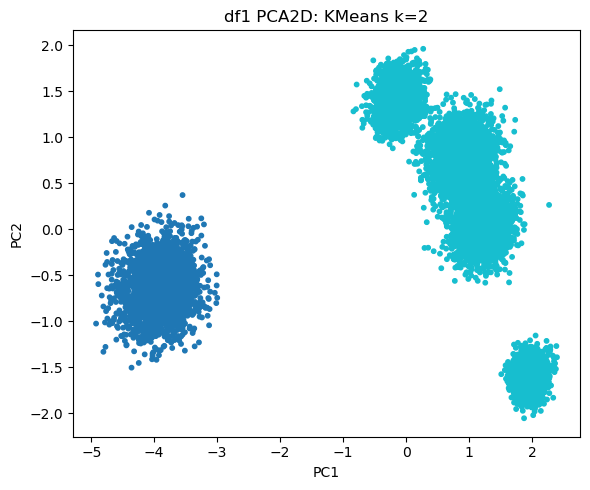

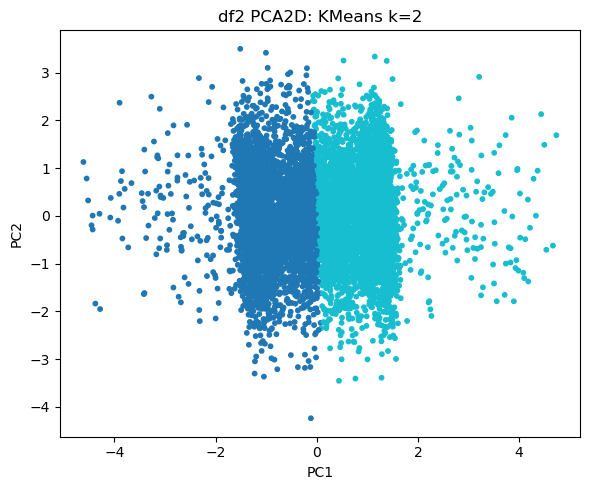

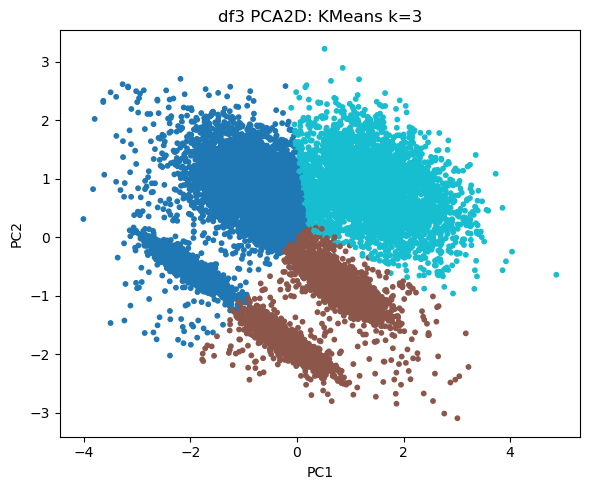

In [314]:
Z1 = PCA(n_components=2, random_state=42).fit_transform(X1p)
plt.figure(figsize=(6,5))
plt.scatter(Z1[:,0], Z1[:,1], c=best_labels1, s=10, cmap="tab10")
plt.title("df1 PCA2D: " + best_name1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("artifacts/figures/df1_best_pca2d.png", dpi=150)
plt.show()

Z2 = PCA(n_components=2, random_state=42).fit_transform(X2p)
plt.figure(figsize=(6,5))
plt.scatter(Z2[:,0], Z2[:,1], c=best_labels2, s=10, cmap="tab10")
plt.title("df2 PCA2D: " + best_name2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("artifacts/figures/df2_best_pca2d.png", dpi=150)
plt.show()

Z3 = PCA(n_components=2, random_state=42).fit_transform(X3p)
plt.figure(figsize=(6,5))
plt.scatter(Z3[:,0], Z3[:,1], c=best_labels3, s=10, cmap="tab10")
plt.title("df3 PCA2D: " + best_name3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("artifacts/figures/df3_best_pca2d.png", dpi=150)
plt.show()


#### 2.3.6. Устойчивость (обязательно, но только для одного датасета)

Выберите **один** из ваших датасетов и проведите мини-проверку устойчивости:

- для KMeans: 5 запусков с разными `random_state` (или 5 разными подвыборками) и оценка похожести разбиений (например, ARI между результатами), **или**
- любая другая аккуратная проверка устойчивости (кратко описать и обосновать).

In [315]:
k = best_k2
from sklearn.metrics import adjusted_rand_score

seeds = [0, 1, 2, 3, 4]
labels_runs = []

for rs in seeds:
    km = KMeans(n_clusters=k, random_state=rs, n_init=10)
    labels = km.fit_predict(X2p)
    labels_runs.append(labels)

base = labels_runs[0]
aris = []
for i in range(1, len(labels_runs)):
    ari = adjusted_rand_score(base, labels_runs[i])
    aris.append(ari)

print("ARI vs first run:", aris)
print("mean ARI:", float(np.mean(aris)), "min ARI:", float(np.min(aris)))

ARI vs first run: [0.9994999999941705, 0.9985003750301323, 0.9994999999941705, 0.9994999999941705]
mean ARI: 0.999250093753161 min ARI: 0.9985003750301323


Сделала 5 запусков KMeans с одним и тем же k (= best_k2), но с разными `random_state`.
Сравнила получившиеся разбиения через ARI (Adjusted Rand Index): ARI = 1 означает одинаковые разбиения (с точностью до перестановки меток) .
У меня ARI почти 1 (mean ≈ 0.999, min ≈ 0.9985), значит результат KMeans на df2 устойчивый, начальная инициализация почти не влияет.

#### 2.3.7. Итог по каждому датасету (обязательно)

Для каждого датасета в конце блока:

- выбрать "лучший" метод/настройку (не обязательно тот, где максимум silhouette – главное, чтобы выбор был объяснён);
- написать 5-10 строк: что получилось, где были сложности (шкалы/выбросы/плотность/пропуски), почему выбранный метод уместен.

## Итог по df1
Лучший метод: **KMeans (k=2)**.  
По метрикам KMeans дал silhouette ≈ 0.522, а DBSCAN — silhouette ≈ 0.384, поэтому по разделению кластеров KMeans лучше.  
DBSCAN почти не выделял шум (noise_frac ≈ 0.0007), то есть как метод “по выбросам” здесь он особо не выигрывает.  
Основная сложность — признаки в разных шкалах, поэтому масштабирование было обязательным.  
Вывод: структура данных довольно “шарообразная”, поэтому KMeans подходит и даёт лучший результат.

## Итог по df2
Лучший метод: **KMeans (k=2)**.  
Лучший silhouette по KMeans получился ≈ 0.307 (k=2), и он оказался наиболее адекватным вариантом из сравниваемых.  
В данных есть шумовой признак `z_noise`, поэтому без масштабирования всё могло “уехать”.  
DBSCAN требовал подбора `eps/min_samples`, и часть комбинаций давала плохие разбиения (после удаления шума иногда оставалось меньше 2 кластеров).  
Вывод: для этого датасета KMeans с k=2 оказался проще и стабильнее.

## Итог по df3
Лучший метод: **KMeans (k=3)**.  
Метрики KMeans: silhouette ≈ 0.316, Davies–Bouldin ≈ 1.158, Calinski–Harabasz ≈ 6957.  
DBSCAN на этом датасете получался более чувствительным к параметрам (особенно к `eps`), поэтому итогово уступил KMeans по качеству/понятности.  
В df3 есть признаки типа `f_corr` и `f_noise`, из‑за этого плотности/шум могут мешать плотностным методам без тонкой настройки.  
Вывод: KMeans с k=3 — самый понятный и воспроизводимый выбор для df3.

In [316]:
import os
os.makedirs("artifacts/labels", exist_ok=True)

pd.DataFrame({"sample_id": df1["sample_id"], "cluster_label": best_labels1}).to_csv(
    "artifacts/labels/labels_hw07_ds1.csv", index=False
)
pd.DataFrame({"sample_id": df2["sample_id"], "cluster_label": best_labels2}).to_csv(
    "artifacts/labels/labels_hw07_ds2.csv", index=False
)
pd.DataFrame({"sample_id": df3["sample_id"], "cluster_label": best_labels3}).to_csv(
    "artifacts/labels/labels_hw07_ds3.csv", index=False
)


In [317]:
import json, os
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/labels", exist_ok=True)

def cluster_metrics(X, labels, is_dbscan=False):
    labels = np.asarray(labels)
    out = {}
    if is_dbscan:
        out["noise_fraction"] = float(np.mean(labels == -1))
        mask = labels != -1
        if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
            out.update({"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None})
            return out
        X_use, y_use = X[mask], labels[mask]
    else:
        out["noise_fraction"] = None
        X_use, y_use = X, labels

    if len(np.unique(y_use)) < 2:
        out.update({"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None})
        return out

    out["silhouette"] = float(silhouette_score(X_use, y_use))
    out["davies_bouldin"] = float(davies_bouldin_score(X_use, y_use))
    out["calinski_harabasz"] = float(calinski_harabasz_score(X_use, y_use))
    return out


best_labels_ds1 = labels_km1
best_labels_ds2 = labels_km2
best_labels_ds3 = labels_km3


metrics_summary = {
  "ds1": {
    "kmeans": cluster_metrics(X1p, labels_km1, is_dbscan=False),
    "dbscan": cluster_metrics(X1p, labels_db1, is_dbscan=True),
  },
  "ds2": {
    "kmeans": cluster_metrics(X2p, labels_km2, is_dbscan=False),
    "dbscan": cluster_metrics(X2p, labels_db2, is_dbscan=True),
  },
  "ds3": {
    "kmeans": cluster_metrics(X3p, labels_km3, is_dbscan=False),
    "dbscan": cluster_metrics(X3p, labels_db3, is_dbscan=True),
  },
}


best_configs = {}

if np.array_equal(best_labels1, labels_km1):
    best_configs["ds1"] = {"best_model": "kmeans", "params": {"k": int(best_k1)}, "criterion": "max_silhouette_vs_dbscan"}
else:
    best_configs["ds1"] = {"best_model": "dbscan", "params": {"eps": float(best_db1["eps"]), "min_samples": int(best_db1["min_samples"])}, "criterion": "max_silhouette_vs_kmeans"}

if np.array_equal(best_labels2, labels_km2):
    best_configs["ds2"] = {"best_model": "kmeans", "params": {"k": int(best_k2)}, "criterion": "max_silhouette_vs_dbscan"}
else:
    best_configs["ds2"] = {"best_model": "dbscan", "params": {"eps": float(best_db2["eps"]), "min_samples": int(best_db2["min_samples"])}, "criterion": "max_silhouette_vs_kmeans"}

if np.array_equal(best_labels3, labels_km3):
    best_configs["ds3"] = {"best_model": "kmeans", "params": {"k": int(best_k3)}, "criterion": "max_silhouette_vs_dbscan"}
else:
    best_configs["ds3"] = {"best_model": "dbscan", "params": {"eps": float(best_db3["eps"]), "min_samples": int(best_db3["min_samples"])}, "criterion": "max_silhouette_vs_kmeans"}


with open("artifacts/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

with open("artifacts/best_configs.json", "w", encoding="utf-8") as f:
    json.dump(best_configs, f, ensure_ascii=False, indent=2)